# Populate categories for 250 random uncategorized permits
This experiment uses Muse Glimmer and adapts the best saved ten-example prompt from `category_analysis_fewshot8.ipynb` to cover **all observed work types**, plus **OUT OF SCOPE**. The original six-category prompt scored 144/172 (83.72%); **the revised abstention prompt has not been accuracy-evaluated**.

Sample 250 unique permit IDs uniformly with seed 42, only when every segment row has a missing category and a usable consistent description. Predictions are exported separately and propagated to sampled segment rows. The original CSV remains intact.

The model may return any observed work type, including TELECOM, or OUT OF SCOPE for unsupported work or insufficient evidence. Abstentions retain their reason and confidence, require review, and **leave proposed and populated work types blank**. Confidence is self-reported, including confidence in abstention, not calibrated accuracy. Most uncategorized permits belong to other permit types, so scope detection needs independent validation.

This research continuation preserves Muse Glimmer and the ten boundary examples, adds up to two observed labeled examples for each additional work type, and includes permit_type as supporting input. Broader examples exclude prior split descriptions. The new prompt is not covered by the original 83.72% score. All work types are discovered from the source CSV; the source labels and CSV are unchanged.

In [1]:
import hashlib, json, os, time, math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from IPython.display import display
from tqdm.auto import tqdm
from openrouter_experiment import OpenRouterPromptClient, MODEL_IDS
from road_ai import DEFAULT_CATEGORIES, classify_one
ROOT = Path.cwd()
load_dotenv(ROOT / '.env.local', override=False)
load_dotenv(ROOT / '.env', override=False)
SEED, N_SAMPLES, MAX_WORKERS = 42, 250, 8
STAGING_CATEGORIES = list(DEFAULT_CATEGORIES)
OUT_OF_SCOPE = 'OUT OF SCOPE'
taxonomy_data = pd.read_csv(ROOT / 'pgh data.csv', low_memory=False)
ALL_WORK_TYPES = sorted(taxonomy_data.work_type.dropna().astype(str).str.strip().str.upper().loc[lambda x: x.ne('')].unique())
CATEGORIES = ALL_WORK_TYPES + [OUT_OF_SCOPE]
# Compare completed saved runs, retaining failures in the denominator.
comparisons = []
for path in (ROOT / 'category_results_fewshot8_openrouter').glob('*/classification_results.csv'):
    frame = pd.read_csv(path)
    for model, group in frame.groupby('model'):
        if len(group) != 172 or group.permit_id.nunique() != 172:
            continue
        comparisons.append(dict(run_dir=str(path.parent), model=model,
                                accuracy=group.actual.eq(group.predicted).mean(), n=len(group)))
ranking = pd.DataFrame(comparisons).sort_values(['accuracy', 'model'], ascending=[False, True])
display(ranking)
selected = ranking.iloc[0]
SOURCE_RUN = Path(selected.run_dir)
MODEL = selected.model
BASE_SYSTEM_PROMPT = (SOURCE_RUN / 'system_prompt.txt').read_text()
# Broader examples are observed labels, not inferred category definitions.
# Exclude all prior development/evaluation descriptions from added examples.
def normalize_description(text):
    return ' '.join(str(text).upper().split())
reserved = set()
for split in (ROOT / 'category_splits').glob('*.csv'):
    split_frame = pd.read_csv(split)
    if 'work_description' in split_frame:
        reserved.update(split_frame.work_description.map(normalize_description))
labeled = taxonomy_data.dropna(subset=['permit_id', 'work_type', 'work_description']).copy()
labeled['work_type'] = labeled.work_type.str.strip().str.upper()
labeled['normalized_description'] = labeled.work_description.map(normalize_description)
# Omit permits and descriptions with conflicting labels; retain full descriptions.
consistent_ids = labeled.groupby('permit_id').work_type.nunique().loc[lambda x: x.eq(1)].index
consistent_descriptions = labeled.groupby('normalized_description').work_type.nunique().loc[lambda x: x.eq(1)].index
labeled = labeled[labeled.permit_id.isin(consistent_ids) &
                  labeled.normalized_description.isin(consistent_descriptions) &
                  labeled.normalized_description.ne('') &
                  ~labeled.normalized_description.isin(reserved)]
labeled = labeled.sort_values('permit_id').drop_duplicates('normalized_description')
expanded_examples = []
for category in ALL_WORK_TYPES:
    if category in STAGING_CATEGORIES:
        continue  # Preserve the ten verified boundary examples for these categories.
    candidates = labeled[labeled.work_type.eq(category)]
    chosen = candidates.sample(min(2, len(candidates)), random_state=SEED)
    for row in chosen.itertuples(index=False):
        expanded_examples.append(dict(permit_id=row.permit_id, permit_type=row.permit_type,
                                      description=row.work_description, category=category))
SYSTEM_PROMPT = BASE_SYSTEM_PROMPT.replace(
    'into exactly one allowed construction-staging category.',
    'into exactly one allowed work-type category across the full dataset taxonomy.',
).replace(
    "Allowed categories: " + ', '.join(STAGING_CATEGORIES) + '.',
    "Allowed categories: " + ', '.join(CATEGORIES) + '.',
).replace(
    'If wording is ambiguous, choose the single best allowed category.',
    'Choose the best supported work type; abstain when evidence is insufficient.',
) + """
Full-taxonomy rules (take precedence over construction-staging guidance above):
The ten preceding examples explain staging boundaries only. First determine whether the
main requested work is staging, excavation, restoration, moving, utility infrastructure,
banner/antenna installation, or another allowed function. Do not force non-staging work into MACHINERY.
Use permit_type as supporting context, not as a work_type label or a guarantee of scope.
GENERAL EXCAVATION covers supported digging/opening or utility repair excavation.
RESTORATION versus TEMPORARY RESTORATION requires evidence of final/permanent versus interim restoration.
TELECOM, POLE, ANTENNA and banner categories require evidence of that infrastructure/function.
MOVING VEHICLE and MOVING CONTAINER are distinct; choose duration-specific container categories
only when that duration is stated. Otherwise choose MOVING CONTAINER.
DOMI APPROVED CAPITAL UTILITY PROJECT and DOMI APPROVED STAND ALONE SERVICE LINES PROJECT
require explicit administrative approval/project evidence; do not invent approval from utility wording.
Do not infer ANNUAL, a banner position, or an exact duration from a vague description.
Use the observed labeled examples below as dataset precedents, not universal keyword rules.
Choose OUT OF SCOPE only for work unsupported by the full allowed taxonomy or insufficient
information to distinguish plausible categories. TELECOM, excavation, poles and restoration
are now supported and must not trigger abstention simply because they are not staging.
Return JSON with category, confidence between 0 and 1, and reason under 20 words.
For OUT OF SCOPE, begin reason with UNSUPPORTED_ACTIVITY: or INSUFFICIENT_EVIDENCE:
and explain briefly. Self-reported confidence is not measured accuracy.
""" + "\nAdditional observed full-taxonomy examples:\n" + "\n".join(
    json.dumps(example, ensure_ascii=False) for example in expanded_examples)
assert all(category in SYSTEM_PROMPT for category in CATEGORIES)
display(pd.DataFrame(expanded_examples))
print('Allowed observed work types:', len(ALL_WORK_TYPES), '; additional labeled examples:', len(expanded_examples))
print('Selected:', MODEL, MODEL_IDS[MODEL], 'accuracy:', selected.accuracy)


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,run_dir,model,accuracy,n
2,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,muse-glimmer,0.837209,172
5,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,muse-glimmer,0.808140,172
3,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,gpt-oss-120b,0.784884,172
0,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,gpt-oss-120b,0.767442,172
4,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,llama-4-scout,0.750000,172
1,/Users/maxhowarth/Desktop/pgh_road_ai_starter/...,llama-4-scout,0.726744,172


,permit_id,permit_type,description,category
0,DOMI-BN-2021-09398,BANNER,THE PROPOSED PROJECT INVOLVES THE REPLACEMENT ...,ANNUAL
1,DOMI-SWF-2022-09867,SMALL CELL WIRELESS FACILITY,WIRELESS COMMUNICATION ANTENNA AND ASSOCIATED ...,ANTENNA
2,DOMI-SWF-2022-14979,SMALL CELL WIRELESS FACILITY,STRIP DISTRICT SC 1: INSTALLMENT OF SMALL CELL...,ANTENNA
3,DOMI-OP-2025-07198,OPENING,SMALL DIAMETER WATER MAIN INSTALLATION AND REP...,DOMI APPROVED CAPITAL UTILITY PROJECT
4,DOMI-OP-2025-09768,OPENING,SMALL DIAMETER WATER MAIN INSTALLATION AND REP...,DOMI APPROVED CAPITAL UTILITY PROJECT
5,DOMI-OP-2025-15213,OPENING,WATER SERVICE LINE VERIFICATION AND LEAD SERVI...,DOMI APPROVED STAND ALONE SERVICE LINES PROJECT
6,DOMI-OP-2025-00632,OPENING,WATER SERVICE LINE VERIFICATIONS AND LEAD SERV...,DOMI APPROVED STAND ALONE SERVICE LINES PROJECT
7,DOMI-BN-2026-01100,BANNER,PITTSBURGH IS HOSTING THE HUMANE WORLD FOR ANI...,EVENT ON-POLE BANNER
8,DOMI-BN-2026-02590,BANNER,"8 ZOO COMMUNITY ""DINOSAURS"" BANNERS HANGING ON...",EVENT ON-POLE BANNER
9,DOMI-OP-2024-00415,OPENING,POLE RESTORATION• WE WILL EXCAVATE A HOLE AS W...,GENERAL EXCAVATION


Allowed observed work types: 21 ; additional labeled examples: 21
Selected: muse-glimmer meta/muse-glimmer-30b accuracy: 0.8372093023255814


In [2]:
raw = pd.read_csv(ROOT / 'pgh data.csv', low_memory=False)
missing = raw.work_type.fillna('').str.strip().eq('')
usable = raw.work_description.fillna('').str.strip().ne('')
valid_id = raw.permit_id.notna() & raw.permit_id.astype(str).str.strip().ne('')
audit = raw.assign(missing=missing, usable=usable).loc[valid_id].groupby('permit_id').agg(
    all_missing=('missing', 'all'), all_usable=('usable', 'all'),
    descriptions=('work_description', 'nunique'), segment_rows=('permit_id', 'size'))
eligible_ids = audit.index[audit.all_missing & audit.all_usable & audit.descriptions.eq(1)]
permits = raw[raw.permit_id.isin(eligible_ids)].drop_duplicates('permit_id').sort_values('permit_id')
sample = permits[['permit_id', 'permit_type', 'work_description']].sample(N_SAMPLES, random_state=SEED).reset_index(drop=True)
sample = sample.merge(audit[['segment_rows']], left_on='permit_id', right_index=True, validate='one_to_one')
sample['within_evaluated_permit_type'] = sample.permit_type.eq('CONSTRUCTION STAGING')
assert sample.permit_id.nunique() == N_SAMPLES
settings = dict(model=MODEL, model_id=MODEL_IDS[MODEL], prompt=SYSTEM_PROMPT,
                seed=SEED, n_samples=N_SAMPLES, max_workers=MAX_WORKERS,
                allowed_categories=CATEGORIES, prompt_variant='full_taxonomy_boundary_examples_v2',
                input_fields=['work_description', 'permit_type'], timeout=45, sdk_retries=1, temperature=0, selection='uniform unique permit; all rows missing')
fingerprint = hashlib.sha256((json.dumps(settings, sort_keys=True) + sample.to_csv(index=False)).encode()).hexdigest()[:16]
OUT = ROOT / 'category_population_250' / fingerprint
OUT.mkdir(parents=True, exist_ok=True)
(OUT / 'run_settings.json').write_text(json.dumps(settings, indent=2))
(OUT / 'system_prompt.txt').write_text(SYSTEM_PROMPT)
sample.to_csv(OUT / 'sampled_permits.csv', index=False)
print(f'{len(raw):,} rows; {missing.sum():,} missing-category rows ({missing.mean():.1%}).')
print(f'{len(audit):,} unique permits; {audit.all_missing.sum():,} entirely uncategorized; {len(permits):,} eligible.')
print('Saved to', OUT)
display(sample.permit_type.value_counts().rename('sampled_permits').to_frame())

(OUT / 'additional_examples.json').write_text(json.dumps(expanded_examples, indent=2))


73,344 rows; 20,139 missing-category rows (27.5%).
53,748 unique permits; 11,419 entirely uncategorized; 11,319 eligible.
Saved to /Users/maxhowarth/Desktop/pgh_road_ai_starter/category_population_250/7dfb1a306b9f48e6


,sampled_permits
permit_type,
OPENING,168
POLE,37
SIDEWALK REPAIR,22
GENERAL PERMIT,17
UTILITY OPENING,3
FINAL RESTORATION,2
BASE REPAIR,1


7607

## Live requests and resumable timing
Requests use the selected saved prompt with the explicit abstention rules appended and existing OpenRouter adapter. Each unique permit is classified once, even when descriptions repeat across different permits. A single preflight precedes eight concurrent workers. Valid checkpointed responses, including OUT OF SCOPE, are reused. The revised prompt has a distinct run fingerprint, so earlier prompt results cannot be reused accidentally. Per-request elapsed time includes SDK retries and response parsing; batch wall time is separate. Failures are retained with no filled category. Confidence values outside [0,1] are flagged and excluded from confidence analysis. Five consecutive failures stop further scheduling.

## Existing labeled confidence evidence (offline)
This section can run without contacting OpenRouter. The live run and its timing analysis follow.

These results describe the original six-category prompt, not the revised abstention prompt.

In [3]:
# This calibration uses existing local labeled results; no API requests.
evaluation = pd.read_csv(SOURCE_RUN / 'classification_results.csv')
evaluation['correct'] = evaluation.actual.eq(evaluation.predicted)
evaluation['confidence_score'] = pd.to_numeric(evaluation.confidence, errors='coerce')
evaluation.loc[~evaluation.confidence_score.between(0,1) | ~evaluation.predicted.isin(CATEGORIES), 'confidence_score'] = np.nan
rows = []
for threshold in [0, .7, .8, .9, .95]:
    subset = evaluation[evaluation.confidence_score.ge(threshold)]
    rows.append(dict(confidence_threshold=threshold, labeled_permits=len(subset),
                     coverage=len(subset)/len(evaluation), observed_accuracy=subset.correct.mean(),
                     mean_confidence=subset.confidence_score.mean()))
prior_confidence = pd.DataFrame(rows)
display(prior_confidence)
prior_confidence.to_csv(OUT / 'prior_evaluation_confidence.csv', index=False)
print('This is diagnostic in-domain evidence, not accuracy of the 250 unlabeled permits.')


,confidence_threshold,labeled_permits,coverage,observed_accuracy,mean_confidence
0,0.00,497,0.963178,0.806841,0.872515
1,0.70,437,0.846899,0.844394,0.923822
2,0.80,395,0.765504,0.860759,0.944329
3,0.90,348,0.674419,0.882184,0.959713
4,0.95,253,0.490310,0.916996,0.977510


This is diagnostic in-domain evidence, not accuracy of the 250 unlabeled permits.


In [4]:
checkpoint = OUT / 'predictions.jsonl'
cached = {}
if checkpoint.exists():
    for line in checkpoint.read_text().splitlines():
        if line.strip():
            record = json.loads(line)
            cached[record['permit_id']] = record
assert set(cached) <= set(sample.permit_id)
client = OpenRouterPromptClient(SYSTEM_PROMPT, timeout=45)
def predict(row):
    started = time.perf_counter()
    result = dict(permit_id=row.permit_id, predicted=None, confidence=None,
                  reason=None, error=None, prompt_tokens=None, completion_tokens=None)
    try:
        answer = classify_one(json.dumps(dict(work_description=row.work_description, permit_type=row.permit_type)), MODEL, CATEGORIES, client=client)
        result.update(predicted=answer['category'], confidence=answer.get('confidence'),
                      reason=answer.get('reason'), prompt_tokens=answer.get('prompt_tokens'),
                      completion_tokens=answer.get('completion_tokens'))
    except Exception as exc:
        result['error'] = str(exc)
    result['elapsed_seconds'] = time.perf_counter() - started
    return result
def save(result):
    with checkpoint.open('a') as handle:
        handle.write(json.dumps(result) + '\n')
    cached[result['permit_id']] = result
pending = [row for row in sample.itertuples(index=False)
           if row.permit_id not in cached or cached[row.permit_id].get('error')]
started = time.perf_counter()
new_results = []
if pending:
    first = predict(pending[0]); save(first); new_results.append(first)
    if first['error']:
        raise RuntimeError('Preflight failed; checkpoint saved: ' + first['error'])
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
        rows = iter(pending[1:]); active = {}; failures = 0; stopped = False
        def fill():
            while not stopped and len(active) < MAX_WORKERS:
                row = next(rows, None)
                if row is None: break
                active[pool.submit(predict, row)] = row.permit_id
        fill()
        with tqdm(total=len(pending), initial=1, desc=MODEL) as progress:
            while active:
                future = next(as_completed(active))
                active.pop(future)
                result = future.result(); save(result); new_results.append(result); progress.update()
                failures = failures + 1 if result['error'] else 0
                if failures >= 5: stopped = True
                fill()
batch_seconds = time.perf_counter() - started
invocation = dict(new_requests=len(new_results), reused=len(sample)-len(pending),
                  batch_seconds=batch_seconds, completed_at=pd.Timestamp.now(tz='UTC').isoformat())
with (OUT / 'timing_history.jsonl').open('a') as handle:
    handle.write(json.dumps(invocation) + '\n')
results = sample.merge(pd.DataFrame(list(cached.values())), on='permit_id', how='left', validate='one_to_one')
results['prediction_success'] = results.predicted.isin(CATEGORIES) & results.error.isna()
results['confidence_numeric'] = pd.to_numeric(results.confidence, errors='coerce')
results['confidence_valid'] = results.confidence_numeric.between(0, 1) & ~results.confidence.map(lambda x: isinstance(x, bool))
results['confidence_score'] = results.confidence_numeric.where(results.confidence_valid & results.prediction_success)
results['abstained'] = results.prediction_success & results.predicted.eq(OUT_OF_SCOPE)
results['category_assigned'] = results.prediction_success & ~results.abstained
results['proposed_work_type'] = results.predicted.where(results.category_assigned)
results['requires_review'] = (results.abstained | ~results.prediction_success |
                              results.confidence_score.isna() | results.confidence_score.lt(.9))
results['prediction_status'] = np.select(
    [results.category_assigned, results.abstained, results.error.notna()],
    ['ASSIGNED', 'OUT OF SCOPE', 'FAILED'], default='NOT COMPLETED')
results.to_csv(OUT / 'permit_predictions.csv', index=False)
segments = raw[raw.permit_id.isin(sample.permit_id)].merge(
    results[['permit_id', 'proposed_work_type', 'confidence_score', 'reason', 'requires_review']],
    on='permit_id', validate='many_to_one')
assert segments.work_type.fillna('').str.strip().eq('').all()
segments['work_type_populated'] = segments.work_type.where(segments.work_type.notna(), segments.proposed_work_type)
segments.to_csv(OUT / 'sampled_segment_rows_populated.csv', index=False)
print(invocation)
print('Valid responses:', results.prediction_success.sum(), '/', N_SAMPLES, '; exported segment rows:', len(segments))

print('Categories assigned:', int(results.category_assigned.sum()), '; OUT OF SCOPE:', int(results.abstained.sum()))


muse-glimmer: 100%|██████████| 250/250 [02:02<00:00,  2.04it/s]

{'new_requests': 250, 'reused': 0, 'batch_seconds': 124.90600316700147, 'completed_at': '2026-10-06T17:32:13.620063+00:00'}
Valid responses: 250 / 250 ; exported segment rows: 452
Categories assigned: 225 ; OUT OF SCOPE: 25


## Confidence, timing, and empirical reliability
The reliability plot uses the selected run's original labeled evaluation, with failures counted as incorrect in overall accuracy. Confidence-bin accuracies and Wilson intervals are conditional on valid successful responses. Thresholds are exploratory, not independently validated. The new 250 predictions have no known labels and therefore have no measured accuracy. Timing extrapolations assume unchanged provider throughput and workload.

Prior calibration is contextual evidence only: the new prompt changes behavior. Sample confidence distributions include OUT OF SCOPE, and assigned versus abstained confidence is reported separately. Abstention coverage is measurable here; abstention correctness is not measurable without human labels.

## Historical six-category abstention run
The local completed run `c4f888dccb9eb735` predates the expanded taxonomy. The following analysis reads its saved predictions without making API calls. Its results must not be presented as results of the new prompt.

In [5]:
historical_path = ROOT / 'category_population_250' / 'c4f888dccb9eb735' / 'permit_predictions.csv'
if historical_path.exists():
    historical = pd.read_csv(historical_path)
    display(historical.predicted.value_counts(dropna=False).rename('permits').to_frame())
    display(historical.groupby('permit_type').agg(total=('permit_id','size'), abstained=('abstained','sum')))
    print('Blank proposed categories:', historical.proposed_work_type.isna().sum(),
          '; explicit OUT OF SCOPE:', historical.predicted.eq(OUT_OF_SCOPE).sum(),
          '; request errors:', historical.error.notna().sum())
    display(historical[historical.predicted.eq(OUT_OF_SCOPE)][['permit_type','work_description','reason']].head(15))
else:
    print('Historical local outputs unavailable.')


,permits
predicted,
OUT OF SCOPE,247
MACHINERY,3


,total,abstained
permit_type,,
BASE REPAIR,1,1
FINAL RESTORATION,2,2
GENERAL PERMIT,17,17
OPENING,168,165
POLE,37,37
SIDEWALK REPAIR,22,22
UTILITY OPENING,3,3


Blank proposed categories: 247 ; explicit OUT OF SCOPE: 247 ; request errors: 0


,permit_type,work_description,reason
0,OPENING,REPAIR GAS LEAKALLENDALE CIR (NATHAN WAY TO FE...,Repair gas leak is utility work without suppor...
1,OPENING,NEIGHBORHOOD LEAD SERVICE LINE REPLACEMENTS,Lead service line replacement is utility excav...
2,OPENING,CATCH BASIN REPLACEMENTSCATCH BASINS ARE NEAR ...,Catch basin replacement is utility excavation ...
3,OPENING,REPLACEMENT AND INSTALLATION OF SMALL DIAMETER...,Water main and service line replacement is uti...
4,OPENING,REPLACE EXISTING VALVEJOB COMPLETE,Valve replacement is utility work with no supp...
5,OPENING,NEW HYDRANTJOB COMPLETEHAMILTON AVE,Description indicates completed hydrant work w...
6,POLE,POLE REPLACEMENT AND RELOCATION OF POLE TAGGED...,Pole replacement/relocation is utility pole wo...
7,OPENING,INSTALL NEW MANHOLE. THIS WORK IS IN COORDINA...,Utility manhole/waterline/catch basin replacem...
8,OPENING,MAINLINE WORK FOR IMPROVEMENT OF OPERATIONAL C...,Description indicates general roadway/mainline...
9,SIDEWALK REPAIR,REPLACE SMALL SECTION OF SIDEWALK AT FRONT OF ...,Sidewalk repair is outside construction-stagin...


,permits,percent_of_sample
prediction_status,,
ASSIGNED,225,90.0
OUT OF SCOPE,25,10.0
FAILED,0,0.0
NOT COMPLETED,0,0.0


NaN in original work_type is expected: sampling selected missing labels.
NaN in proposed_work_type/populated work_type means no category was assigned: check prediction_status.
OUT OF SCOPE is a valid abstention, FAILED is a request/response error, NOT COMPLETED has no result.
NaN confidence is missing/invalid confidence, not an out-of-scope indicator.
Assignment coverage: 90.0%; abstention rate: 10.0%.


,total,assigned,abstained,abstention_rate
permit_type,,,,
BASE REPAIR,1,1,0,0.000000
FINAL RESTORATION,2,2,0,0.000000
GENERAL PERMIT,17,6,11,0.647059
OPENING,168,157,11,0.065476
POLE,37,35,2,0.054054
SIDEWALK REPAIR,22,22,0,0.000000
UTILITY OPENING,3,2,1,0.333333


,permits,percent_of_abstentions
abstention_cause,,
Insufficient evidence (model report),16,64.0
Unsupported activity (model report),9,36.0


,permit_id,permit_type,work_description,reason,confidence_score
13,DOMI-OP-2021-04575,OPENING,SIDEWALK OPENING PERMIT.,INSUFFICIENT_EVIDENCE: description is only 'SI...,0.15
25,DOMI-UOP-2026-07432,UTILITY OPENING,PENN AVE PHASE II CITY PROJECT - 1C THROUGH 1J,INSUFFICIENT_EVIDENCE: description is only pro...,0.15
39,DOMI-PL-2021-11699,POLE,PIT_LAWRENCEVILLE_0009_W2PIT_SQUIRREL_HILL_003...,INSUFFICIENT_EVIDENCE: description contains on...,0.10
41,DOMI-GEN-2026-11071,GENERAL PERMIT,PARKING FOR ONE (1) 45' TOUR BUS ON 09/26 - 09...,UNSUPPORTED_ACTIVITY: parking a tour bus is no...,0.85
42,DOMI-OP-2022-16443,OPENING,NEW TAP,INSUFFICIENT_EVIDENCE: description 'NEW TAP' t...,0.35
54,DOMI-OP-2021-04008,OPENING,NEW SERVICEJOB COMPLETESTANTON AVE,INSUFFICIENT_EVIDENCE: description too sparse ...,0.35
73,DOMI-GEN-2024-02753,GENERAL PERMIT,"ON SATURDAY APRIL 6, 2024 HEINZ HALL HAS AN AR...",UNSUPPORTED_ACTIVITY: parking reservation for ...,0.35
79,DOMI-OP-2023-03332,OPENING,MAIN REPAIRJOB COMPLETED,INSUFFICIENT_EVIDENCE: description too vague t...,0.15
83,DOMI-OP-2021-14878,OPENING,NEW TAP,"INSUFFICIENT_EVIDENCE: description ""NEW TAP"" l...",0.35
84,DOMI-OP-2023-02698,OPENING,LOCATE VALVEJOB COMPLETE,INSUFFICIENT_EVIDENCE: description too sparse ...,0.35


...

Sample confidence summary:


,confidence_score
count,250.000000
mean,0.683360
std,0.201345
min,0.100000
25%,0.605000
50%,0.700000
75%,0.850000
max,0.950000


,request_seconds
count,250.000000
mean,3.870662
std,1.627757
min,1.493008
50%,3.528545
90%,6.166963
95%,7.269248
99%,8.370892
max,9.136418


Network batch wall time across invocations: 124.9s; throughput: 2.00 requests/s
Estimated eligible-pool runtime at observed throughput: 94.3 minutes (rough estimate).
Token totals: {'prompt_tokens': 1135502, 'completion_tokens': 53936}
Failures: 0 invalid/missing confidences: 0
Outside evaluated permit type: 250 / 250


permits  \
permit_type       prediction_status proposed_work_type                                         
BASE REPAIR       ASSIGNED          RESTORATION                                            1   
FINAL RESTORATION ASSIGNED          RESTORATION                                            2   
GENERAL PERMIT    ASSIGNED          BARRICADE                                              1   
                                    GENERAL EXCAVATION                                     1   
                                    MACHINERY                                              1   
                                    MOVING VEHICLE                                         3   
                  OUT OF SCOPE      NaN                                                   11   
OPENING           ASSIGNED          DOMI APPROVED CAPITAL UTILITY PROJECT                  3   
                                    DOMI APPROVED STAND ALONE SERVICE LINES PROJECT       14   
                                    GENERAL EXCAVATION                                    99   
                                    MACHINERY                                              2   
                                    RESTORATION                                           32   
                                    TEMPORARY RESTORATION                                  7   
                  OUT OF SCOPE      NaN                                                   11   
POLE              ASSIGNED          POLE                                                  35   
                  OUT OF SCOPE      NaN                                                    2   
SIDEWALK REPAIR   ASSIGNED          GENERAL EXCAVATION                                     2   
                                    RESTORATION                                           20   
UTILITY OPENING   ASSIGNED          DOMI APPROVED STAND ALONE SERVICE LINES PROJECT        1   
                                    GENERAL EXCAVATION                                     1   
                  OUT OF SCOPE      NaN                                                    1   

                                                                                     mean_confidence  
permit_type       prediction_status proposed_work_type                                                
BASE REPAIR       ASSIGNED          RESTORATION                                             0.700000  
FINAL RESTORATION ASSIGNED          RESTORATION                                             0.950000  
GENERAL PERMIT    ASSIGNED          BARRICADE                                               0.450000  
                                    GENERAL EXCAVATION                                      0.450000  
                                    MACHINERY                                               0.650000  
                                    MOVING VEHICLE                                          0.456667  
                  OUT OF SCOPE      NaN                                                     0.648182  
OPENING           ASSIGNED          DOMI APPROVED CAPITAL UTILITY PROJECT                   0.933333  
                                    DOMI APPROVED STAND ALONE SERVICE LINES PROJECT         0.850000  
                                    GENERAL EXCAVATION                                      0.683838  
                                    MACHINERY                                               0.900000  
                                    RESTORATION                                             0.579688  
                                    TEMPORARY RESTORATION                                   0.835714  
                  OUT OF SCOPE      NaN                                                     0.320909  
POLE              ASSIGNED          POLE                                                    0.859143  
                  OUT OF SCOPE      NaN                                                     0.100000  
SIDEWALK REPAIR   ASSI

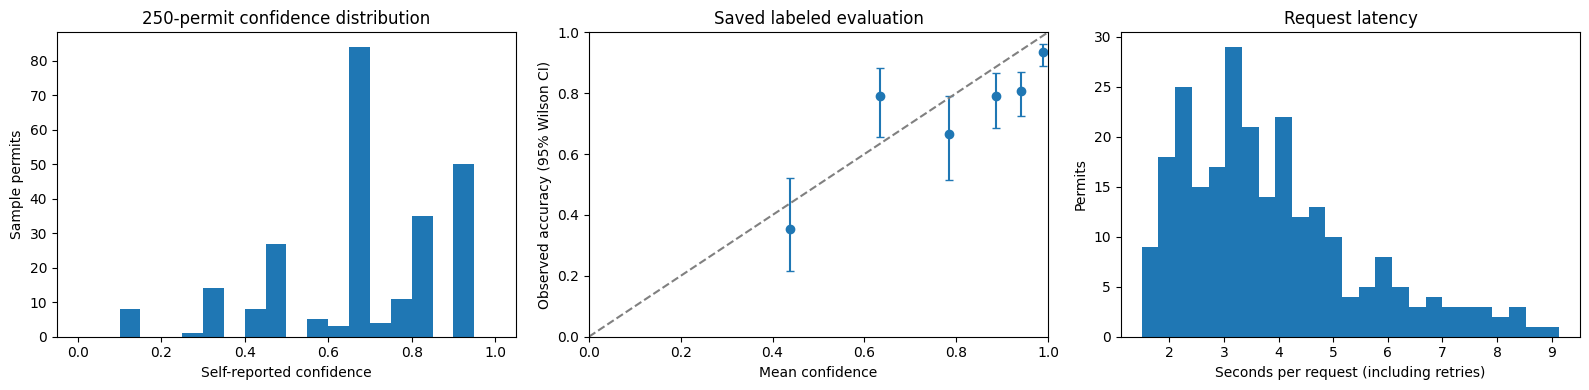

,permit_id,permit_type,work_description,proposed_work_type,confidence_score,reason,requires_review
39,DOMI-PL-2021-11699,POLE,PIT_LAWRENCEVILLE_0009_W2PIT_SQUIRREL_HILL_003...,NaN,0.10,INSUFFICIENT_EVIDENCE: description contains on...,True
165,DOMI-PL-2022-01270,POLE,PIT_SHERADEN_006,NaN,0.10,INSUFFICIENT_EVIDENCE: work description is onl...,True
211,DOMI-GEN-2025-04977,GENERAL PERMIT,WORK IS TO OCCUR INSIDE ALBERT “TURK” GRAHAM P...,NaN,0.10,INSUFFICIENT_EVIDENCE: no work type details pr...,True
13,DOMI-OP-2021-04575,OPENING,SIDEWALK OPENING PERMIT.,NaN,0.15,INSUFFICIENT_EVIDENCE: description is only 'SI...,True
25,DOMI-UOP-2026-07432,UTILITY OPENING,PENN AVE PHASE II CITY PROJECT - 1C THROUGH 1J,NaN,0.15,INSUFFICIENT_EVIDENCE: description is only pro...,True
79,DOMI-OP-2023-03332,OPENING,MAIN REPAIRJOB COMPLETED,NaN,0.15,INSUFFICIENT_EVIDENCE: description too vague t...,True
212,DOMI-GEN-2020-00426,GENERAL PERMIT,BRIDGE WASHING FOR PENNDOT ECMS 106389 BRIDGE ...,NaN,0.15,UNSUPPORTED_ACTIVITY: bridge washing cleaning ...,True
244,DOMI-OP-2021-06403,OPENING,MAIN LEAKJOB COMPLETE,NaN,0.15,INSUFFICIENT_EVIDENCE: description 'MAIN LEAKJ...,True
140,DOMI-OP-2022-13477,OPENING,LOCATE VALVEJOB COMPLETE,NaN,0.30,INSUFFICIENT_EVIDENCE: description too vague t...,True
42,DOMI-OP-2022-16443,OPENING,NEW TAP,NaN,0.35,INSUFFICIENT_EVIDENCE: description 'NEW TAP' t...,True


In [6]:
# Explain blank values and quantify usefulness as coverage, not confidence alone.
status = results.prediction_status.value_counts().reindex(['ASSIGNED','OUT OF SCOPE','FAILED','NOT COMPLETED'], fill_value=0).to_frame('permits')
status['percent_of_sample'] = 100 * status.permits / len(results)
display(status)
print('NaN in original work_type is expected: sampling selected missing labels.')
print('NaN in proposed_work_type/populated work_type means no category was assigned: check prediction_status.')
print('OUT OF SCOPE is a valid abstention, FAILED is a request/response error, NOT COMPLETED has no result.')
print('NaN confidence is missing/invalid confidence, not an out-of-scope indicator.')
print(f'Assignment coverage: {results.category_assigned.mean():.1%}; abstention rate: {results.abstained.mean():.1%}.')
by_type = results.groupby('permit_type', dropna=False).agg(total=('permit_id','size'), assigned=('category_assigned','sum'), abstained=('abstained','sum'))
by_type['abstention_rate'] = by_type.abstained / by_type.total
display(by_type)
abstentions = results[results.abstained].copy()
def abstention_cause(reason):
    text = str(reason).upper()
    if text.startswith('UNSUPPORTED_ACTIVITY:'): return 'Unsupported activity (model report)'
    if text.startswith('INSUFFICIENT_EVIDENCE:'): return 'Insufficient evidence (model report)'
    return 'Unspecified reason; manual review needed'
abstentions['abstention_cause'] = abstentions.reason.map(abstention_cause)
causes = abstentions.abstention_cause.value_counts().to_frame('permits')
causes['percent_of_abstentions'] = 100 * causes.permits / max(len(abstentions), 1)
display(causes)
display(abstentions[['permit_id','permit_type','work_description','reason','confidence_score']].head(20))
status.to_csv(OUT / 'prediction_status_summary.csv')
by_type.to_csv(OUT / 'abstention_by_permit_type.csv')
abstentions.to_csv(OUT / 'abstention_review.csv', index=False)
causes.to_csv(OUT / 'abstention_causes.csv')
if results.abstained.mean() > .2:
    print('Abstention exceeds 20% (exploratory coverage flag, not a validated acceptance threshold).')
    print('Review the reasons and examples: unsupported activities suggest taxonomy gaps; insufficient evidence suggests sparse descriptions or overlapping labels.')
else:
    print('Abstention is a smaller portion of the sample; human labels are still needed to establish whether assigned categories are correct.')
print('A lower abstention rate is useful only if accuracy of assigned categories remains acceptable.')

evaluation = pd.read_csv(SOURCE_RUN / 'classification_results.csv')
evaluation['correct'] = evaluation.actual.eq(evaluation.predicted)
evaluation['confidence_score'] = pd.to_numeric(evaluation.confidence, errors='coerce')
evaluation.loc[~evaluation.confidence_score.between(0, 1) | ~evaluation.predicted.isin(STAGING_CATEGORIES), 'confidence_score'] = np.nan
bins = [0, .5, .7, .8, .9, .95, 1]
labels = ['0–.50', '.50–.70', '.70–.80', '.80–.90', '.90–.95', '.95–1.00']
for frame in [results, evaluation]:
    frame['confidence_bin'] = pd.cut(frame.confidence_score, bins=bins, labels=labels, include_lowest=True)
confidence_table = results.groupby('confidence_bin', observed=False).agg(
    sample_count=('permit_id', 'size'), mean_confidence=('confidence_score', 'mean'))
calibration = evaluation.groupby('confidence_bin', observed=False).agg(
    labeled_count=('correct', 'size'), correct=('correct', 'sum'),
    mean_confidence=('confidence_score', 'mean'), empirical_accuracy=('correct', 'mean'))
z = 1.96
count = calibration.labeled_count.replace(0, np.nan)
p = calibration.empirical_accuracy
denom = 1 + z*z/count
center = (p + z*z/(2*count))/denom
half = z*np.sqrt(p*(1-p)/count + z*z/(4*count*count))/denom
calibration['wilson_low'] = center-half
calibration['wilson_high'] = center+half
display(confidence_table.join(calibration, rsuffix='_evaluation'))
threshold_rows = []
for threshold in [0, .7, .8, .9, .95]:
    subset = evaluation[evaluation.confidence_score.ge(threshold)]
    threshold_rows.append(dict(threshold=threshold, labeled_n=len(subset),
        labeled_coverage=len(subset)/len(evaluation), labeled_accuracy=subset.correct.mean(),
        sample_assigned_n=int((results.category_assigned & results.confidence_score.ge(threshold)).sum()), sample_abstained_n=int((results.abstained & results.confidence_score.ge(threshold)).sum())))
thresholds = pd.DataFrame(threshold_rows)
display(thresholds)
valid = evaluation.dropna(subset=['confidence_score'])
ece = (calibration.labeled_count * (calibration.mean_confidence-calibration.empirical_accuracy).abs()).sum()/len(valid)
brier = ((valid.confidence_score-valid.correct.astype(float))**2).mean()
print(f'Saved evaluation accuracy (including failures): {evaluation.correct.mean():.2%}; ECE: {ece:.3f}; Brier score for correctness: {brier:.3f}')
print('Confidence below includes abstentions; inspect assigned and abstained groups separately.')
display(results.groupby('abstained').confidence_score.describe())
print('Sample confidence summary:'); display(results.confidence_score.describe().to_frame())
latency = results.elapsed_seconds.dropna()
display(latency.describe(percentiles=[.5, .9, .95, .99]).to_frame('request_seconds'))
history = [json.loads(line) for line in (OUT / 'timing_history.jsonl').read_text().splitlines()]
network_wall = sum(item['batch_seconds'] for item in history if item['new_requests'])
requests = sum(item['new_requests'] for item in history)
throughput = requests/network_wall if network_wall else np.nan
print(f'Network batch wall time across invocations: {network_wall:.1f}s; throughput: {throughput:.2f} requests/s')
print(f'Estimated eligible-pool runtime at observed throughput: {len(permits)/throughput/60:.1f} minutes (rough estimate).')
print('Token totals:', results[['prompt_tokens','completion_tokens']].sum().to_dict())
print('Failures:', int((~results.prediction_success).sum()), 'invalid/missing confidences:', int((~results.confidence_valid).sum()))
print('Outside evaluated permit type:', int((~results.within_evaluated_permit_type).sum()), '/', len(results))
display(results.groupby(['permit_type', 'prediction_status', 'proposed_work_type'], dropna=False).agg(
    permits=('permit_id','size'), mean_confidence=('confidence_score','mean')))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(results.confidence_score.dropna(), bins=np.linspace(0,1,21)); axes[0].set(xlabel='Self-reported confidence', ylabel='Sample permits', title='250-permit confidence distribution')
plot = calibration.dropna(subset=['empirical_accuracy'])
axes[1].errorbar(plot.mean_confidence, plot.empirical_accuracy,
    yerr=[plot.empirical_accuracy-plot.wilson_low, plot.wilson_high-plot.empirical_accuracy], fmt='o', capsize=3)
axes[1].plot([0,1],[0,1], '--', color='gray'); axes[1].set(xlim=(0,1), ylim=(0,1), xlabel='Mean confidence', ylabel='Observed accuracy (95% Wilson CI)', title='Saved labeled evaluation')
axes[2].hist(latency, bins=25); axes[2].set(xlabel='Seconds per request (including retries)', ylabel='Permits', title='Request latency')
fig.tight_layout(); fig.savefig(OUT / 'confidence_and_timing.png', dpi=160); plt.show()
confidence_table.to_csv(OUT / 'confidence_distribution.csv')
calibration.to_csv(OUT / 'evaluation_calibration.csv')
thresholds.to_csv(OUT / 'confidence_thresholds.csv', index=False)
metrics = dict(successful=int(results.prediction_success.sum()), total=N_SAMPLES, assigned=int(results.category_assigned.sum()), abstained=int(results.abstained.sum()),
    out_of_scope=int(results.abstained.sum()), outside_original_evaluation_type=int((~results.within_evaluated_permit_type).sum()),
    mean_confidence=float(results.confidence_score.mean()), evaluation_accuracy=float(evaluation.correct.mean()),
    evaluation_ece=float(ece), evaluation_brier=float(brier), network_wall_seconds=network_wall,
    requests_per_second=throughput, median_latency=float(latency.median()), p95_latency=float(latency.quantile(.95)))
(OUT / 'analysis_summary.json').write_text(json.dumps(metrics, indent=2))
review = results.sort_values(['within_evaluated_permit_type', 'confidence_score'], na_position='first')
review.to_csv(OUT / 'manual_review_queue.csv', index=False)
display(review[['permit_id','permit_type','work_description','proposed_work_type','confidence_score','reason','requires_review']].head(25))


## Is this a good method?
The earlier six-category abstention run returned **247/250 OUT OF SCOPE (98.8%)**, assigned three MACHINERY labels, and had zero request failures. Its 247 blank proposed categories were deliberate abstentions. All original work_type values were missing by sampling design. Missing confidence or incomplete/failed requests are separate conditions.

The sample contained 168 OPENING, 37 POLE, 22 SIDEWALK REPAIR, 17 GENERAL PERMIT, three UTILITY OPENING, two FINAL RESTORATION and one BASE REPAIR permits. Thus the main problem was taxonomy coverage: clear gas-leak repairs, water/service-line replacements, pole work and sidewalk repairs were excluded by a staging-only prompt. Some descriptions were sparse (for example, “CORROSION”), while others described a clear activity without stating a staging function. These are distinct reasons; the historical run did not provide independently validated cause counts.

This continuation retains the best saved model, Muse Glimmer, and its ten category-boundary examples, expands allowed outputs to every work type observed in the CSV, adds observed examples for the additional labels, and supplies permit_type as supporting context. OUT OF SCOPE now means unsupported by the full taxonomy or insufficient evidence, rather than simply outside the six staging categories. The distinct run fingerprint preserves the earlier experiment for comparison.

The goal is high useful coverage with acceptable assigned-category accuracy, not merely a low abstention rate. Broader categories should address the observed scope mismatch, but the new run must establish the effect; no improvement is assumed. The original 83.72% accuracy and calibration belong to the original tuned staging prompt and do not validate this expanded prompt. Administrative approvals, duration-specific labels, vague descriptions and inconsistent labels may still require abstention.

Before automatic population, manually label a representative sample and independently measure assigned-category accuracy, per-work-type accuracy, coverage, scope precision/recall and calibration. Use the reason breakdown as model-reported evidence, not verified causation. Timing measures feasibility rather than correctness. All predictions remain reviewable exports; OUT OF SCOPE leaves the populated work type blank, and the source CSV is unchanged.